In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re                         

medical  = pd.read_csv('medical_records.csv')
patients = pd.read_csv('patient_details.csv')
 

print("  ORIGINAL medical_records.csv\n")
print(medical)
 
print("\n")
print("  ORIGINAL patient_details.csv\n")
print(patients)

  ORIGINAL medical_records.csv

   patient_id admission_date     diagnosis height_cm      bp  sugar_level  \
0        P001     2024/01/15      Diabetes       170  120/80         95.0   
1        P002     15-02-2024  Hypertension    165abc    high        140.0   
2        P003     2024/03/10      Diabetes       180  130/85          NaN   
3        P004     10.04.2024         Fever       155  110/70         88.0   
4        P005     2024/05/22        Asthma       175    high        102.0   
5        P006     22-06-2024      Diabetes       160  125/82          NaN   
6        P007     2024/07/18         Fever       185  115/75         91.0   
7        P008     18.08.2024  Hypertension    150xyz    high        155.0   
8        P009     2024/09/05        Asthma       172  128/84         98.0   
9        P010     05-10-2024      Diabetes       168    high          NaN   
10       P011     2024/11/12         Fever       178  118/76         85.0   
11       P012     12.12.2024  Hypertension  

In [4]:
#Merging datasets on patient_id using inner join
df = pd.merge(medical, patients, on='patient_id', how='inner')
print("After INNER JOIN on patient_id")
print(df)

After INNER JOIN on patient_id
   patient_id admission_date     diagnosis height_cm      bp  sugar_level  \
0        P001     2024/01/15      Diabetes       170  120/80         95.0   
1        P002     15-02-2024  Hypertension    165abc    high        140.0   
2        P003     2024/03/10      Diabetes       180  130/85          NaN   
3        P004     10.04.2024         Fever       155  110/70         88.0   
4        P005     2024/05/22        Asthma       175    high        102.0   
5        P006     22-06-2024      Diabetes       160  125/82          NaN   
6        P007     2024/07/18         Fever       185  115/75         91.0   
7        P008     18.08.2024  Hypertension    150xyz    high        155.0   
8        P009     2024/09/05        Asthma       172  128/84         98.0   
9        P010     05-10-2024      Diabetes       168    high          NaN   
10       P011     2024/11/12         Fever       178  118/76         85.0   
11       P012     12.12.2024  Hypertension   

In [5]:
#Imputing null values in name cols.
df['name'] = df['name'].fillna('Unknown')
print("Nulls in 'name' replaced with 'Unknown'")
print(df['name'])

  (ii) Nulls in 'name' replaced with 'Unknown'
0       Alice
1         Bob
2     Unknown
3       Diana
4         Eve
5     Unknown
6       Grace
7     Unknown
8        Ivan
9        Judy
10    Unknown
11        Leo
Name: name, dtype: object


In [6]:
#Rectifying negative values in age col
df['age'] = df['age'].abs()
print("Negative values in 'age' corrected")
print(df['age'])

Negative values in 'age' corrected
0     28
1     35
2     22
3     30
4     25
5     19
6     45
7     32
8     27
9     38
10    29
11    23
Name: age, dtype: int64


In [7]:
# Making gender col consistent
df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female'})
print("Gender values made consistent")
print(df['gender'].value_counts()) 

Gender values made consistent
gender
Female    6
Male      6
Name: count, dtype: int64


In [8]:
# Making case values in city col consistent
df['city'] = df['city'].str.title()
print(" City values in Title Case")
print(df['city'])

 City values in Title Case
0        Mumbai
1         Delhi
2     Bangalore
3       Chennai
4     Hyderabad
5          Pune
6       Kolkata
7        Mumbai
8         Delhi
9     Bangalore
10      Chennai
11    Hyderabad
Name: city, dtype: object


In [9]:
# Making date col of admission_date consistent using regex
def fix_date(date_str):
    date_str = str(date_str).strip()
 
   
    match = re.match(r'^(\d{4})[/](\d{2})[/](\d{2})$', date_str)
    if match:
        return f"{match.group(1)}-{match.group(2)}-{match.group(3)}"
 
   
    match = re.match(r'^(\d{2})[-](\d{2})[-](\d{4})$', date_str)
    if match:
        return f"{match.group(3)}-{match.group(2)}-{match.group(1)}"
 

    match = re.match(r'^(\d{2})[.](\d{2})[.](\d{4})$', date_str)
    if match:
        return f"{match.group(3)}-{match.group(2)}-{match.group(1)}"
 
    return date_str   # return as-is if nothing matches
 
 
df['admission_date'] = df['admission_date'].apply(fix_date)
print(" admission_date made consistent (YYYY-MM-DD)")
print(df['admission_date'])

 admission_date made consistent (YYYY-MM-DD)
0     2024-01-15
1     2024-02-15
2     2024-03-10
3     2024-04-10
4     2024-05-22
5     2024-06-22
6     2024-07-18
7     2024-08-18
8     2024-09-05
9     2024-10-05
10    2024-11-12
11    2024-12-12
Name: admission_date, dtype: object


In [11]:
# Striping non-numeric characters using regex(convert to float)
df['height_cm'] = df['height_cm'].astype(str)
df['height_cm'] = df['height_cm'].apply(lambda x: re.sub(r'[^0-9.]', '', x))
# Convert to numeric (empty strings become NaN)
df['height_cm'] = pd.to_numeric(df['height_cm'], errors='coerce')
# Impute NaN with mean
height_mean = df['height_cm'].mean()
df['height_cm'] = df['height_cm'].fillna(round(height_mean, 1))
print(" Height_cm cleaned & nulls imputed with mean")
print(df['height_cm'])

 Height_cm cleaned & nulls imputed with mean
0     170
1     165
2     180
3     155
4     175
5     160
6     185
7     150
8     172
9     168
10    178
11    163
Name: height_cm, dtype: int64


In [12]:
# Replace “high” from bp column with 140/90
df['bp'] = df['bp'].replace('high', '140/90')
print("'high' in bp replaced with '140/90'")
print(df['bp'])

'high' in bp replaced with '140/90'
0     120/80
1     140/90
2     130/85
3     110/70
4     140/90
5     125/82
6     115/75
7     140/90
8     128/84
9     140/90
10    118/76
11    140/90
Name: bp, dtype: object


In [13]:
#IMPUTE 'sugar_level' nulls with MEAN
sugar_mean = df['sugar_level'].mean()
df['sugar_level'] = df['sugar_level'].fillna(round(sugar_mean, 2))
print(f" sugar_level nulls imputed with mean = {round(sugar_mean,2)}")
print(df['sugar_level'])

 sugar_level nulls imputed with mean = 111.33
0      95.00
1     140.00
2     111.33
3      88.00
4     102.00
5     111.33
6      91.00
7     155.00
8      98.00
9     111.33
10     85.00
11    148.00
Name: sugar_level, dtype: float64


In [14]:
# FINAL CLEANED DATASET
print(" FINAL CLEANED DATASET")
print(df.to_string(index=False))

 FINAL CLEANED DATASET
patient_id admission_date    diagnosis  height_cm     bp  sugar_level  visit_cost    name  age gender      city
      P001     2024-01-15     Diabetes        170 120/80        95.00        1500   Alice   28 Female    Mumbai
      P002     2024-02-15 Hypertension        165 140/90       140.00        2000     Bob   35   Male     Delhi
      P003     2024-03-10     Diabetes        180 130/85       111.33        1800 Unknown   22 Female Bangalore
      P004     2024-04-10        Fever        155 110/70        88.00         800   Diana   30 Female   Chennai
      P005     2024-05-22       Asthma        175 140/90       102.00        2500     Eve   25 Female Hyderabad
      P006     2024-06-22     Diabetes        160 125/82       111.33        1600 Unknown   19   Male      Pune
      P007     2024-07-18        Fever        185 115/75        91.00         900   Grace   45   Male   Kolkata
      P008     2024-08-18 Hypertension        150 140/90       155.00        2200

In [15]:
#GROUP BY 'gender' - mean, min, max of visit_cost

grouped = df.groupby('gender')['visit_cost'].agg(
    Mean_Visit_Cost = 'mean',
    Min_Visit_Cost  = 'min',
    Max_Visit_Cost  = 'max'
).reset_index()
print(" GROUP BY Gender → visit_cost stats")
print(grouped.to_string(index=False))

 GROUP BY Gender → visit_cost stats
gender  Mean_Visit_Cost  Min_Visit_Cost  Max_Visit_Cost
Female      1750.000000             800            2500
  Male      1641.666667             850            2400


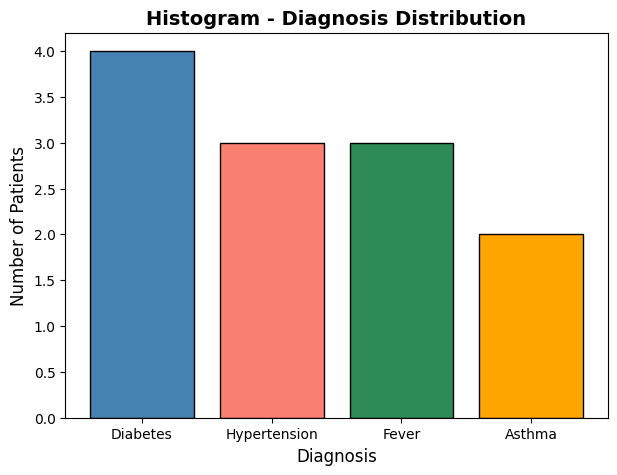

In [22]:
# HISTOGRAM on 'diagnosis' column
diagnosis_counts = df['diagnosis'].value_counts()
plt.figure(figsize=(7, 5))
bars = plt.bar(diagnosis_counts.index,diagnosis_counts.values,
    color=['steelblue', 'salmon', 'seagreen', 'orange'],edgecolor='black')
plt.title('Histogram - Diagnosis Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

plt.show()